In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    f1_score,
    roc_curve,
    auc
)

plt.rcParams['figure.figsize']=(7,5)

Building a Simple Decision Tree (Synthetic Data)

In [15]:
##Create a small synthetic dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy':   [0,        1,       0,        1,        0,        1,        0,       1],
    'Play':    [1,        0,       1,        1,        0,        0,        1,       0]
}
df_synthetic = pd.DataFrame(data)
df_synthetic

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


In [16]:
#Encode categorical feature and prepare x,y
df_synthetic['Weather_num']=df_synthetic['Weather'].map({'Sunny':1, 'Rainy':0})
x_syn=df_synthetic[['Weather_num','Windy']]
y_syn=df_synthetic['Play']
print(x_syn)
print(y_syn)

   Weather_num  Windy
0            1      0
1            0      1
2            1      0
3            1      1
4            0      0
5            0      1
6            1      0
7            0      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: Play, dtype: int64


#Train a simple decision tree

In [17]:
tree_syn=DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(x_syn,y_syn)
tree_syn

DecisionTreeClassifier(max_depth=3, random_state=42)

#Visualize the tree

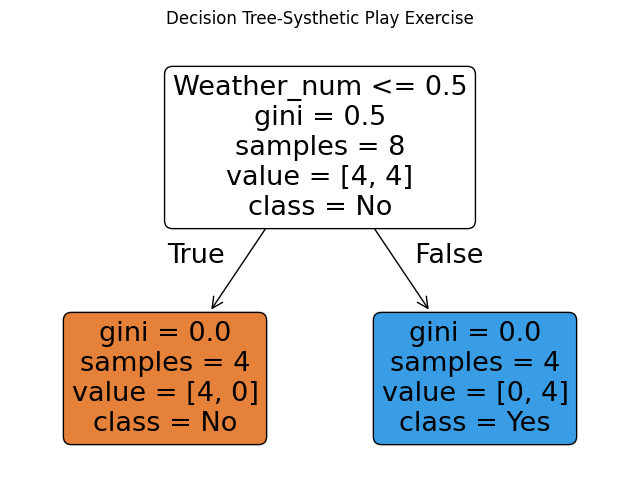

In [18]:
plt.figure(figsize=(8,6))
plot_tree(
    tree_syn,
    feature_names=['Weather_num','Windy'],
    class_names=['No','Yes'],
    filled=True,
    rounded=True,
    )
plt.title('Decision Tree-Systhetic Play Exercise')
plt.show()

In [19]:
from sklearn import tree
# Ex:Sunny (1), not windy (0)
example_1=pd.DataFrame([[1,0]], columns=['Weather_num', 'Windy'])
pred_1=tree_syn.predict(example_1)[0]
print('Sunny, not windy -> Play prediction: ',pred_1)

# Ex:Rainy (0), windy (1)
example_2=pd.DataFrame([[0,1]], columns=['Weather_num','Windy'])
pred_2 = tree_syn.predict(example_2)[0]
print('Rainy, windy -> Play prediction: ',pred_2)

Sunny, not windy -> Play prediction:  1
Rainy, windy -> Play prediction:  0


#Overfitting and Pruning

 Create a slightly larger synthetic dataset

In [20]:
from sklearn.datasets import  make_classification

X_big, y_big= make_classification(
    n_samples=400,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)


X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(X_big, y_big, test_size=0.3, random_state=42)

X_train_big.shape, X_test_big.shape

((280, 5), (120, 5))

#Train a deep tree vs a pruned tree

In [21]:
deep_tree= DecisionTreeClassifier(random_state=43)
deep_tree.fit(X_train_big, y_train_big)

pruned_tree=DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_big,y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_pruned = pruned_tree.predict(X_train_big)
y_test_pred_pruned = pruned_tree.predict(X_test_big)

print('Deep tree– train accuracy:', round(accuracy_score(y_train_big, y_train_pred_deep), 3))
print('Deep tree– test accuracy :', round(accuracy_score(y_test_big, y_test_pred_deep), 3))
print()
print('Pruned tree– train accuracy:', round(accuracy_score(y_train_big, y_train_pred_pruned), 3))
print('Pruned tree– test accuracy :', round(accuracy_score(y_test_big, y_test_pred_pruned), 3))


Deep tree– train accuracy: 1.0
Deep tree– test accuracy : 0.875

Pruned tree– train accuracy: 0.904
Pruned tree– test accuracy : 0.892


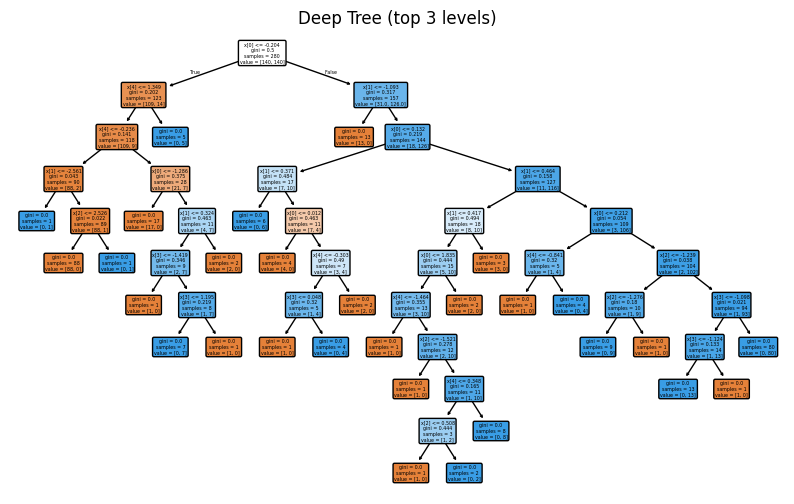

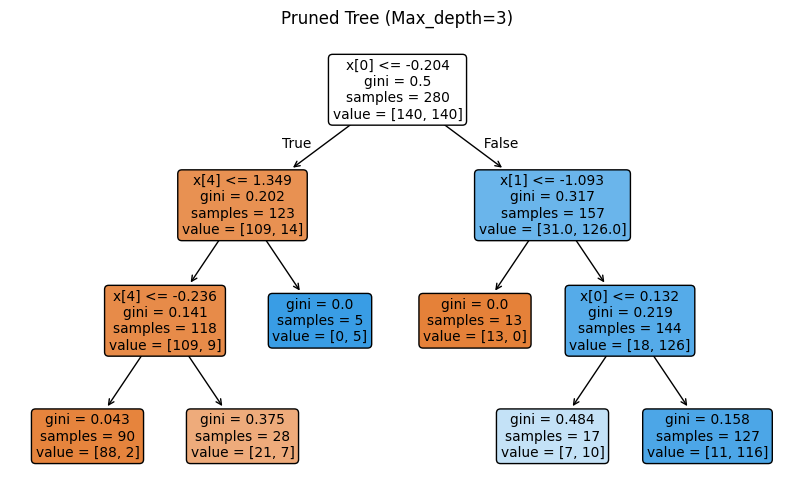

In [22]:
# Plot deep tree (showing only top level for readability)
plt.figure(figsize=(10,6))
plot_tree(deep_tree, filled=True,rounded=True)
plt.title("Deep Tree (top 3 levels)")
plt.show()
# Plot pruned tree
plt.figure(figsize=(10,6))
plot_tree(pruned_tree, filled=True,rounded=True)
plt.title("Pruned Tree (Max_depth=3)")
plt.show()